# BayesNF — seasonality ablation (Time-input layer)

Goal: understand how the BayesNF time-seasonality parameters
(`seasonality_periods`, `num_seasonal_harmonics`) affect daily precipitation
interpolation quality.

Seasonality is encoded as sin/cos pairs:

$$\Phi_{\text{seas}}(t) = \Big\{ \cos(2\pi h\,t/p),\ \sin(2\pi h\,t/p) \Big\}_{h=1\ldots H,\ p \in P}$$

where $P$ is `seasonality_periods` (for daily data, `['Y']` means $p=365.25$;
`['W','Y']` adds a weekly $p=7$) and $H$ is `num_seasonal_harmonics` per
period. Larger $H$ can capture sharper seasonal transitions but risks
overfitting.

What we vary:
- `seasonality_periods`: `['Y']` vs `['W','Y']`
- `num_seasonal_harmonics`: 1, 3, 4, 10

What we fix:
- 5 years (2018–2022), fold 0
- Features: DEM + SoilGrids (no FFRK, no NWP). `elevation_m` sits at
  **index 3** in `feature_cols` so pairs `(0,3), (1,3), (2,3)` in
  `interactions` reference elevation (time×DEM, lat×DEM, lon×DEM — the
  orographic effect with seasonal modulation).
- Likelihood: **ZINB** (zero-inflated negative binomial — winner of the
  likelihood ablation on `crps_wet` for discrete count-style precipitation).
  Target is `rainfall_int = round(10·mm)`; after `predict` we divide by
  `PRECIP_SCALE=10` to recover mm.
- Architecture: width=256, depth=2, 100 epochs, ensemble=4 per device.
- Everything else: `BayesianNeuralFieldVI` defaults.

Metrics: CRPS (quantiles 5/50/95), MAE, RMSE, bias — on all points and on
wet-only ($y \ge 0.5$ mm, canonical definition from chapter 7).

Structure: setup + data + JIT patch + `train_eval(...)` helper run once at the
top, then one cell per experiment.


## 1. Environment and imports


In [1]:
import os
# JAX env vars must be set BEFORE the first `import jax`
os.environ.setdefault('JAX_LOG_COMPILES', '0')   # silence noise (JIT patch below)
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.90')

import sys
import gc
import time
import json
import threading
from pathlib import Path

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import bayesnf
from bayesnf.spatiotemporal import BayesianNeuralFieldVI

jax.config.update('jax_default_matmul_precision', 'tensorfloat32')

# Repo root: notebooks/05_bayesnf/time_seasonality/<this>.ipynb -> ../../..
ROOT = Path('../../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

print(f'cwd      : {os.getcwd()}')
print(f'bayesnf  : {getattr(bayesnf, "__version__", "n/a")}')


cwd      : /root/precip_interpolation_thesis
bayesnf  : 0.1.3


## 2. GPU diagnostics


In [2]:
import subprocess

backend = jax.default_backend()
devices = jax.devices()
print(f'JAX backend : {backend}')
print(f'JAX devices : {devices}')
print(f'n local     : {jax.local_device_count()}')

if backend != 'gpu':
    print('\nJAX is running on CPU; this notebook is intended for GPU.')

try:
    smi = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.used,memory.total',
         '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5,
    )
    print('\nnvidia-smi:')
    print(smi.stdout)
except Exception as e:
    print(f'nvidia-smi unavailable: {e}')


JAX backend : gpu
JAX devices : [CudaDevice(id=0), CudaDevice(id=1)]
n local     : 2

nvidia-smi:
NVIDIA L40S, 435 MiB, 46068 MiB
NVIDIA L40S, 435 MiB, 46068 MiB



## 3. Experiment config

Fix likelihood (**ZINB**), architecture, features, years. Only seasonality
changes between the cells below.

Feature order matters. `interactions` indexes `feature_cols` positionally.
`elevation_m` sits at index 3, so pairs `(0,3)`, `(1,3)`, `(2,3)` give
time × DEM (seasonal modulation of the orographic effect), lat × DEM and
lon × DEM (local topography). Base pairs `(0,1), (0,2), (1,2)` are the
standard space-time interactions.

ZINB target: `rainfall_int = round(10·mm)`. After predict we divide mean and
quantiles by `PRECIP_SCALE = 10` to recover mm. Metrics (CRPS, MAE, RMSE) are
computed on `rainfall` (mm) against rescaled predictions — apples-to-apples
with kriging and LGBM.


In [3]:
# --- Likelihood and target ---
LIKELIHOOD    = 'ZINB'          # zero-inflated NB (winner of likelihood ablation)
TARGET_COL    = 'rainfall_int'  # round(10*mm), integer counts
NEEDS_RESCALE = True            # ZINB -> *0.1 after predict
PRECIP_SCALE  = 10

# --- Data window (5 years) ---
FOLD       = 0
YEAR_START = 2018
YEAR_END   = 2023

# --- Features: DEM + SoilGrids, NO FFRK, NO NWP ---
# IMPORTANT: elevation_m is at index 3, referenced by interactions
# (0,3), (1,3), (2,3) in the helper below.
# x_proj/y_proj are NOT included: they are a linear function of lat/lon
# (EPSG:3035 projection), so for BayesNF they are duplicates that would only
# dilute the Covariate Scaling Layer. lat/lon already suffice — BayesNF
# builds its spatial Fourier features from them.
FEATURE_COLS = [
    'datetime', 'latitude', 'longitude', 'elevation_m',   # idx 0,1,2,3
    'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa',
]
STANDARDIZE_COLS = [c for c in FEATURE_COLS if c != 'datetime']

# --- Interactions ---
# (0,1), (0,2) -- time x space (frontal movement)
# (1,2)        -- lat x lon (field geometry)
# (0,3)        -- time x DEM (seasonal modulation of orographic effect)
# (1,3), (2,3) -- space x DEM (local topography)
INTERACTIONS = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

# --- Architecture (fixed across ablation variants) ---
WIDTH         = 256
DEPTH         = 2
NUM_EPOCHS    = 50
BATCH_SIZE    = 131072
LEARNING_RATE = 0.1
KL_WEIGHT     = 0.1
ENSEMBLE_SIZE = 16
SEED          = 0

# --- Output ---
OUT_DIR = Path('results/bayesnf/experiments/time_seasonality')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'likelihood   : {LIKELIHOOD}  (target={TARGET_COL}, rescale={NEEDS_RESCALE})')
print(f'years        : {YEAR_START}-{YEAR_END}, fold {FOLD}')
print(f'features     : {FEATURE_COLS}')
print(f'interactions : {INTERACTIONS}')
print(f'   -> DEM (elevation_m) at idx 3:  {FEATURE_COLS[3]}')
print(f'out dir      : {OUT_DIR}')


likelihood   : ZINB  (target=rainfall_int, rescale=True)
years        : 2018-2023, fold 0
features     : ['datetime', 'latitude', 'longitude', 'elevation_m', 'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
interactions : [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
   → DEM (elevation_m) at idx 3:  elevation_m
out dir      : results/bayesnf/experiments/time_seasonality


## 4. Load data (5 years, fold 0)


In [4]:
S3_BUCKET   = 'thesis-data-ismaktam'
DATA_S3_DIR = 'bayesnf/data'
DATA_DIR    = Path('results/bayesnf/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / f'bayesnf_fold{FOLD}_train.parquet'
test_path  = DATA_DIR / f'bayesnf_fold{FOLD}_test.parquet'

def _ensure_local(local_path: Path, s3_key: str) -> None:
    if local_path.exists():
        print(f'  cache hit: {local_path.name} ({local_path.stat().st_size/1e6:.0f} MB)')
        return
    import boto3
    print(f'  downloading s3://{S3_BUCKET}/{s3_key} ...')
    boto3.client('s3').download_file(S3_BUCKET, s3_key, str(local_path))
    print(f'  ↓ {local_path.name} ({local_path.stat().st_size/1e6:.0f} MB)')

_ensure_local(train_path, f'{DATA_S3_DIR}/bayesnf_fold{FOLD}_train.parquet')
_ensure_local(test_path,  f'{DATA_S3_DIR}/bayesnf_fold{FOLD}_test.parquet')

date_filter = [
    ('datetime', '>=', pd.Timestamp(f'{YEAR_START}-01-01')),
    ('datetime', '<=', pd.Timestamp(f'{YEAR_END}-12-31')),
]
KEEP_COLS = FEATURE_COLS + ['rainfall', 'rainfall_int', 'station_id']

df_train = pd.read_parquet(train_path, filters=date_filter)[KEEP_COLS].copy()
df_test  = pd.read_parquet(test_path,  filters=date_filter)[KEEP_COLS].copy()
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_test ['datetime'] = pd.to_datetime(df_test ['datetime'])

assert df_train[FEATURE_COLS].isna().sum().sum() == 0
assert df_test [FEATURE_COLS].isna().sum().sum() == 0
assert 'rainfall_int' in df_train.columns, 'ZINB needs rainfall_int = round(10·mm)'

print(f'train rows / stations : {len(df_train):>10,} / {df_train["station_id"].nunique()}')
print(f'test  rows / stations : {len(df_test):>10,} / {df_test ["station_id"].nunique()}')
print(f'dates                 : {df_train["datetime"].min().date()} → {df_train["datetime"].max().date()}')
print(f'rainfall (mm) range   : [{df_train["rainfall"].min():.2f}, {df_train["rainfall"].max():.2f}]')
print(f'rainfall_int range    : [{df_train["rainfall_int"].min()}, {df_train["rainfall_int"].max()}]')
print(f'%zero (rainfall_int)  : {100*(df_train["rainfall_int"]==0).mean():.1f}%')
df_train.head()


  cache hit: bayesnf_fold0_train.parquet (1320 MB)
  cache hit: bayesnf_fold0_test.parquet (277 MB)
train rows / stations :  3,444,252 / 1572
test  rows / stations :    863,254 / 394
dates                 : 2018-01-01 → 2023-12-31
rainfall (mm) range   : [0.00, 206.80]
rainfall_int range    : [0, 2068]
%zero (rainfall_int)  : 53.5%


,datetime,latitude,longitude,elevation_m,bulk_density,clay,sand,silt,soc,water_10kpa,rainfall,rainfall_int,station_id
0,2018-01-01,50.750000,15.550000,1410.0,105.607903,201.660599,367.390106,430.932465,526.377625,440.415588,4.2,42,CZ_H1VITK01
1,2018-01-01,50.137135,15.462251,213.0,125.099129,306.760834,243.486084,353.339539,225.015762,-721.471436,0.0,0,CZ_H3CHLM01
2,2018-01-01,50.248100,15.198100,208.0,117.473495,337.345032,172.872147,360.899719,195.627258,-1072.900635,0.0,0,CZ_H3DYMO01
3,2018-01-01,50.433300,15.366700,301.0,39.006870,77.082283,69.430191,146.449249,74.091118,-7600.684082,0.0,0,CZ_H3JICI01
4,2018-01-01,50.370822,15.214447,225.0,122.927307,286.541656,115.863037,514.331177,176.030960,-557.900818,0.0,0,CZ_H3LIBA01


## 5. JIT-cache patch for `predict`

Same patch as in the likelihood notebooks: `BayesNF.predict_bnf` creates a new
`forecast_inner` closure on every call, which forces a JIT cache miss and a
recompile per chunk. We cache the pmap'd `forecast_inner` on `self`.


In [ ]:
import bayesnf.inference as bnf_inference
import bayesnf.models as bnf_models
import bayesnf.spatiotemporal as bnf_st


def _patched_predict(self, table, quantiles=(0.5,), approximate_quantiles=False):
    test_data = self.data_handler.get_test(table)
    distribution = bnf_models.LikelihoodDist(self.observation_model)

    if getattr(self, '_cached_forecast_inner', None) is None:
        model_args = self._model_args(test_data.shape)
        fn = bnf_inference._make_forecast_inner(model_args, distribution)
        for _ in range(self._ensemble_dims - 1):
            fn = jax.vmap(fn, in_axes=(0, None))
        fn = jax.pmap(fn, in_axes=(0, None))
        self._cached_forecast_inner = fn

    forecast_inner = self._cached_forecast_inner
    axis = tuple(range(self._ensemble_dims))

    forecast_params = bnf_inference.forecast_parameters_batched(
        test_data, self.params_, distribution, forecast_inner,
        batchsize=16384
    )

    if distribution == bnf_models.LikelihoodDist.NORMAL:
        means, scales = forecast_params
        forecast_means = means
        forecast_quantiles = bnf_inference._get_percentile_normal(
            forecast_means, scales, quantiles, axis=axis,
            approximate=approximate_quantiles,
        )
    elif distribution in (bnf_models.LikelihoodDist.NB, bnf_models.LikelihoodDist.ZINB):
        obs_d = bnf_inference._build_observation_distribution(distribution, forecast_params)
        forecast_means = obs_d.mean()
        forecast_quantiles = jax.vmap(
            lambda q: bnf_inference._get_nb_quantiles_root(obs_d, q, ensemble_axes=axis)
        )(jnp.array(quantiles))
    else:
        raise ValueError(f'Unknown distribution: {distribution}')

    return forecast_means, forecast_quantiles


bnf_st.BayesianNeuralFieldEstimator.predict = _patched_predict
print('✓ patched BayesianNeuralFieldEstimator.predict')


✓ patched BayesianNeuralFieldEstimator.predict


## 6. Helper: `train_eval(name, seasonality_periods, num_seasonal_harmonics)`

One function = one full `fit -> predict -> metrics` pass. Returns a dict of
metrics and saves to `OUT_DIR/<name>/` (preds.parquet, metrics.json,
losses.npy). All results accumulate in the global `RESULTS` list used for the
final comparison.


In [17]:
from properscoring import crps_ensemble

QUANTILES = (0.05, 0.50, 0.95)
QUANTILE_LABELS = [5, 50, 95]
PRED_CHUNK = 500000
WET_THRESHOLD_MM = 0.5    # canonical, from data_study_area.tex:191

RESULTS: list[dict] = []


def train_eval(name: str, seasonality_periods: list, num_seasonal_harmonics: list) -> dict:
    assert len(seasonality_periods) == len(num_seasonal_harmonics), \
        f'len mismatch: periods={seasonality_periods}, harmonics={num_seasonal_harmonics}'

    print(f'\n{"="*70}')
    print(f'  [{name}]  periods={seasonality_periods}  harmonics={num_seasonal_harmonics}')
    print(f'{"="*70}')

    sub_dir = OUT_DIR / name
    sub_dir.mkdir(parents=True, exist_ok=True)

    # --- build model ---
    model = BayesianNeuralFieldVI(
        width=WIDTH, depth=DEPTH,
        freq='D', timetype='index',
        seasonality_periods=seasonality_periods,
        num_seasonal_harmonics=num_seasonal_harmonics,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        standardize=STANDARDIZE_COLS,
        observation_model=LIKELIHOOD,
        interactions=INTERACTIONS,
    )

    # --- fit with heartbeat ---
    stop = threading.Event()
    def _beat():
        t0 = time.time()
        while not stop.wait(20.0):
            print(f'    [{name}] still training ({time.time()-t0:.0f}s)', flush=True)
    thr = threading.Thread(target=_beat, daemon=True); thr.start()

    t0 = time.time()
    try:
        model = model.fit(
            df_train,
            seed=jax.random.PRNGKey(SEED),
            num_epochs=NUM_EPOCHS,
            ensemble_size=ENSEMBLE_SIZE,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            kl_weight=KL_WEIGHT,
        )
    finally:
        stop.set(); thr.join(timeout=1)
    fit_time_s = time.time() - t0
    print(f'  fit done in {fit_time_s:.0f}s ({fit_time_s/60:.1f} min)')

    losses_arr = np.asarray(model.losses_)
    np.save(sub_dir / 'losses.npy', losses_arr)

    # --- predict by chunks ---
    means_chunks, q_chunks = [], []
    t0 = time.time()
    n = len(df_test)
    for i in range(0, n, PRED_CHUNK):
        j = min(i + PRED_CHUNK, n)
        m, q = model.predict(df_test.iloc[i:j], quantiles=QUANTILES, approximate_quantiles=True)
        means_chunks.append(np.asarray(m))
        q_chunks.append(np.asarray(q))
        gc.collect()
    predict_time_s = time.time() - t0
    print(f'  predict {n:,} rows in {predict_time_s:.0f}s')

    means_raw = np.concatenate(means_chunks, axis=-1)
    q_raw     = np.concatenate(q_chunks, axis=-1)
    mean_per_point = means_raw.reshape(-1, n).mean(axis=0)
    q_flat = q_raw.reshape(q_raw.shape[0], -1, n).mean(axis=1)

    # --- rescale int counts -> mm (ZINB target = rainfall_int) ---
    if NEEDS_RESCALE:
        mean_per_point = mean_per_point / PRECIP_SCALE
        q_flat = q_flat / PRECIP_SCALE

    # --- metrics (all in mm; y_true taken from rainfall, not rainfall_int) ---
    y_true = df_test['rainfall'].to_numpy()
    q_arr = np.stack(list(q_flat), axis=1)
    q_arr = np.sort(q_arr, axis=1)

    metrics = {
        'name': name,
        'seasonality_periods': seasonality_periods,
        'num_seasonal_harmonics': num_seasonal_harmonics,
        'rmse'    : float(np.sqrt(np.mean((mean_per_point - y_true) ** 2))),
        'mae'     : float(np.mean(np.abs(mean_per_point - y_true))),
        'bias'    : float(np.mean(mean_per_point - y_true)),
        'cov90'   : float(np.mean((y_true >= q_arr[:, 0]) & (y_true <= q_arr[:, 2]))),
        'crps'    : float(crps_ensemble(y_true, q_arr).mean()),
        'n_total' : int(len(y_true)),
        'fit_time_s'    : float(fit_time_s),
        'predict_time_s': float(predict_time_s),
    }
    wet = y_true >= WET_THRESHOLD_MM
    if wet.sum() > 0:
        metrics['mae_wet']  = float(np.mean(np.abs(mean_per_point[wet] - y_true[wet])))
        metrics['rmse_wet'] = float(np.sqrt(np.mean((mean_per_point[wet] - y_true[wet]) ** 2)))
        metrics['crps_wet'] = float(crps_ensemble(y_true[wet], q_arr[wet]).mean())
        metrics['n_wet']    = int(wet.sum())
    else:
        metrics.update({'mae_wet': float('nan'), 'rmse_wet': float('nan'),
                        'crps_wet': float('nan'), 'n_wet': 0})

    # --- save ---
    with open(sub_dir / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    preds_df = df_test[['station_id', 'datetime']].copy()
    preds_df['observed_mm'] = y_true
    preds_df['mean_mm']     = mean_per_point
    for lbl, qv in zip(QUANTILE_LABELS, q_flat):
        preds_df[f'q{lbl:02d}'] = qv
    preds_df.to_parquet(sub_dir / 'preds.parquet', index=False)

    # --- print summary ---
    print(f'  CRPS     = {metrics["crps"]:.4f}    CRPS_wet = {metrics["crps_wet"]:.4f}')
    print(f'  MAE      = {metrics["mae"]:.4f}    MAE_wet  = {metrics["mae_wet"]:.4f}')
    print(f'  RMSE     = {metrics["rmse"]:.4f}   RMSE_wet = {metrics["rmse_wet"]:.4f}')
    print(f'  bias     = {metrics["bias"]:+.4f}  cov90    = {metrics["cov90"]:.3f}')

    # cleanup GPU memory
    del model
    jax.clear_caches()
    gc.collect()

    RESULTS.append(metrics)
    return metrics


print('helper ready')


✓ helper ready


## 7. Experiments

One cell per model. Run top-to-bottom, inspect the printout. To add a variant,
copy any cell and change the parameters.


### 7.1 Year only, 1 harmonic (baseline — plain annual sine)


In [ ]:
# m = train_eval(name='Y_h1', seasonality_periods=['Y'], num_seasonal_harmonics=[1])

### 7.2 Year only, 3 harmonics (smooth seasonality)


In [ ]:
# m = train_eval(name='Y_h3', seasonality_periods=['Y'], num_seasonal_harmonics=[3])


### 7.3 Year only, 4 harmonics (default from likelihood ablation)


In [ ]:
# m = train_eval(name='Y_h4', seasonality_periods=['Y'], num_seasonal_harmonics=[4])


### 7.4 Year only, 10 harmonics (sharper seasonal transitions)


In [ ]:
# m = train_eval(name='Y_h10', seasonality_periods=['Y'], num_seasonal_harmonics=[10])


### 7.5 Week + Year, [1, 4] (add a weekly cycle)


In [7]:
m = train_eval(name='WY_h1_4', seasonality_periods=['W', 'Y'], num_seasonal_harmonics=[1, 4])



  [WY_h1_4]  periods=['W', 'Y']  harmonics=[1, 4]
    [WY_h1_4] still training (20s)
    [WY_h1_4] still training (40s)
    [WY_h1_4] still training (60s)
    [WY_h1_4] still training (80s)
    [WY_h1_4] still training (100s)
    [WY_h1_4] still training (120s)
    [WY_h1_4] still training (140s)
    [WY_h1_4] still training (160s)
    [WY_h1_4] still training (180s)
    [WY_h1_4] still training (200s)
    [WY_h1_4] still training (220s)
    [WY_h1_4] still training (240s)
    [WY_h1_4] still training (260s)
    [WY_h1_4] still training (280s)
    [WY_h1_4] still training (300s)
    [WY_h1_4] still training (320s)
    [WY_h1_4] still training (340s)
    [WY_h1_4] still training (360s)
    [WY_h1_4] still training (380s)
  ✓ fit done in 387s (6.4 min)
  ✓ predict 863,254 rows in 793s
  CRPS     = 1.3239    CRPS_wet = 3.2352
  MAE      = 1.0145    MAE_wet  = 2.1141
  RMSE     = 2.4268   RMSE_wet = 3.8076
  bias     = +0.2386  cov90    = 0.992


### 7.6 Week + Year, [1, 10]


In [8]:
m = train_eval(name='WY_h1_10', seasonality_periods=['W', 'Y'], num_seasonal_harmonics=[1, 10])



  [WY_h1_10]  periods=['W', 'Y']  harmonics=[1, 10]
    [WY_h1_10] still training (20s)
    [WY_h1_10] still training (40s)
    [WY_h1_10] still training (60s)
    [WY_h1_10] still training (80s)
    [WY_h1_10] still training (100s)
    [WY_h1_10] still training (120s)
    [WY_h1_10] still training (140s)
    [WY_h1_10] still training (160s)
    [WY_h1_10] still training (180s)
    [WY_h1_10] still training (200s)
    [WY_h1_10] still training (220s)
    [WY_h1_10] still training (240s)
    [WY_h1_10] still training (260s)
    [WY_h1_10] still training (280s)
    [WY_h1_10] still training (300s)
    [WY_h1_10] still training (320s)
    [WY_h1_10] still training (340s)
    [WY_h1_10] still training (360s)
    [WY_h1_10] still training (380s)
    [WY_h1_10] still training (400s)
  ✓ fit done in 411s (6.9 min)
  ✓ predict 863,254 rows in 495s
  CRPS     = 1.0666    CRPS_wet = 2.6880
  MAE      = 0.7872    MAE_wet  = 1.7547
  RMSE     = 2.0120   RMSE_wet = 3.2205
  bias     = +0.0997  cov

## 8. Comparison across variants

Bar chart + CSV. `RESULTS` accumulates as cells above are executed; only the
cells that have been run will appear in the summary.


saved: results/bayesnf/experiments/time_seasonality/seasonality_summary.csv

    name seasonality_periods num_seasonal_harmonics     crps  crps_wet      mae  mae_wet     rmse  rmse_wet     bias    cov90  fit_time_s  predict_time_s
 WY_h1_4              [W, Y]                 [1, 4] 1.323904  3.235213 1.014484 2.114096 2.426777  3.807586 0.238584 0.992437  386.843687      793.152732
WY_h1_10              [W, Y]                [1, 10] 1.066572  2.688020 0.787248 1.754702 2.012009  3.220543 0.099676 0.991318  411.469862      495.259644


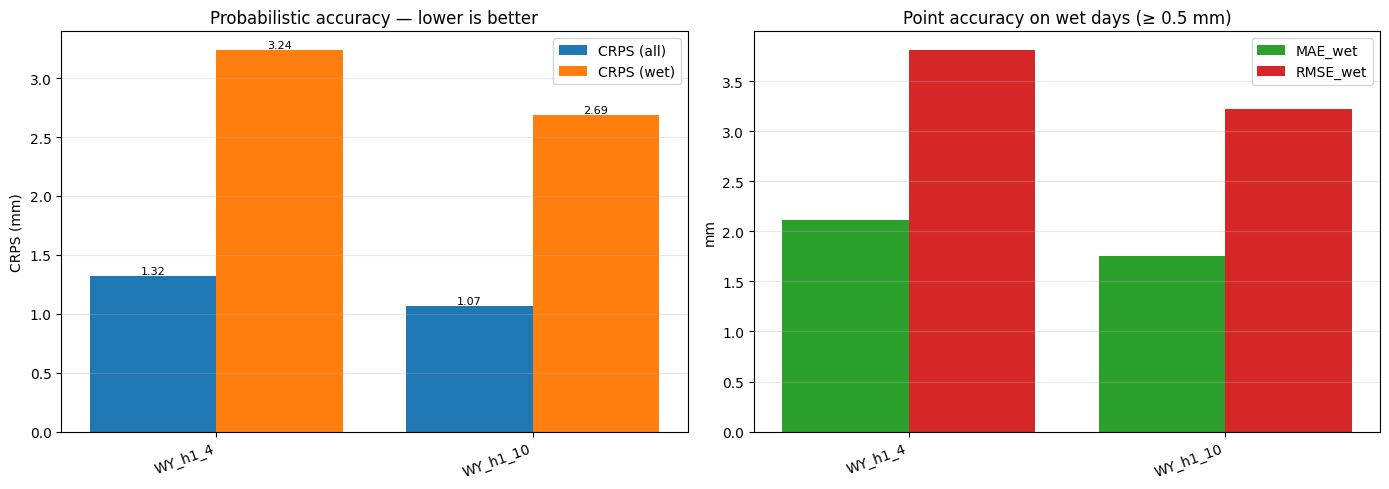

saved: results/bayesnf/experiments/time_seasonality/seasonality_comparison.png

→ best by CRPS_wet: WY_h1_10  (periods=['W', 'Y'], harmonics=[1, 10]) CRPS_wet=2.6880


In [9]:
import matplotlib.pyplot as plt

if not RESULTS:
    raise SystemExit('RESULTS is empty — run at least one cell from section 7.')

summary = pd.DataFrame(RESULTS)
cols = ['name', 'seasonality_periods', 'num_seasonal_harmonics',
        'crps', 'crps_wet', 'mae', 'mae_wet', 'rmse', 'rmse_wet',
        'bias', 'cov90', 'fit_time_s', 'predict_time_s']
summary = summary[[c for c in cols if c in summary.columns]]
csv_path = OUT_DIR / 'seasonality_summary.csv'
summary.to_csv(csv_path, index=False)
print(f'saved: {csv_path}')
print()
print(summary.to_string(index=False))

# --- bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = [r['name'] for r in RESULTS]
x = np.arange(len(names))

ax = axes[0]
ax.bar(x - 0.2, [r['crps']     for r in RESULTS], width=0.4, label='CRPS (all)',  color='C0')
ax.bar(x + 0.2, [r['crps_wet'] for r in RESULTS], width=0.4, label='CRPS (wet)',  color='C1')
for xi, r in zip(x - 0.2, RESULTS):
    ax.text(xi, r['crps'], f'{r["crps"]:.2f}', ha='center', va='bottom', fontsize=8)
for xi, r in zip(x + 0.2, RESULTS):
    ax.text(xi, r['crps_wet'], f'{r["crps_wet"]:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('CRPS (mm)'); ax.set_title('Probabilistic accuracy — lower is better')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - 0.2, [r['mae_wet']  for r in RESULTS], width=0.4, label='MAE_wet',  color='C2')
ax.bar(x + 0.2, [r['rmse_wet'] for r in RESULTS], width=0.4, label='RMSE_wet', color='C3')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('mm'); ax.set_title('Point accuracy on wet days (>= 0.5 mm)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / 'seasonality_comparison.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'saved: {fig_path}')

best = min(RESULTS, key=lambda r: r['crps_wet'])
print(f'\nbest by CRPS_wet: {best["name"]}  '
      f'(periods={best["seasonality_periods"]}, harmonics={best["num_seasonal_harmonics"]}) '
      f'CRPS_wet={best["crps_wet"]:.4f}')


available dates : 2018-01-01 → 2023-12-31  (2191 total)

[2018-07-15]  N stations with obs: 394
  observed  : min=0.00  max=32.00  mean=0.48
  predicted : min=0.01  max=6.05  mean=0.33
  abs error : mean=0.471  max=28.505


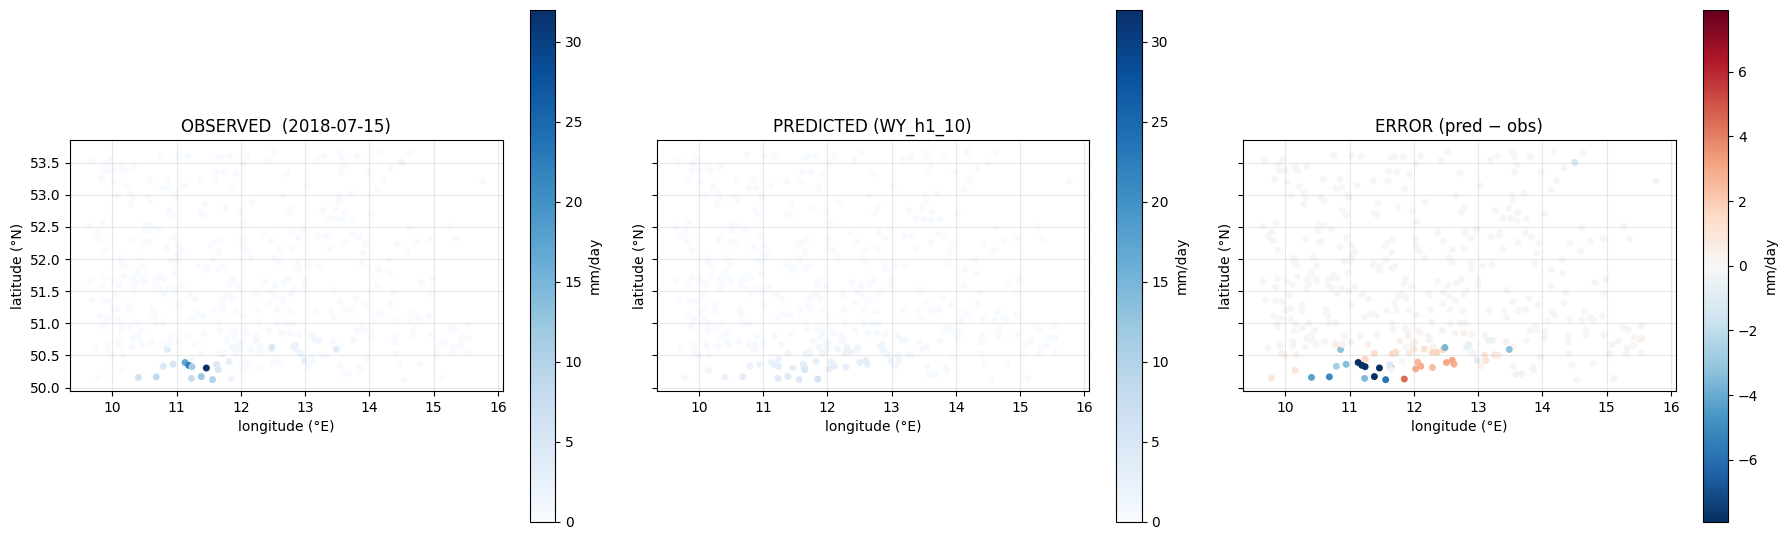

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

MODEL_NAME = 'WY_h1_10'
PICK_DATE  = '2018-07-15'   # pick any date in 2018-2022

# --- load predictions ---
preds = pd.read_parquet(OUT_DIR / MODEL_NAME / 'preds.parquet')
preds['datetime'] = pd.to_datetime(preds['datetime'])

# sanity: available dates
all_dates = preds['datetime'].drop_duplicates().sort_values()
print(f'available dates : {all_dates.min().date()} -> {all_dates.max().date()}  ({len(all_dates)} total)')
assert pd.Timestamp(PICK_DATE) in set(all_dates), f'date {PICK_DATE} not in test-fold'

# --- merge with df_test to recover lat/lon ---
coords = df_test[['station_id', 'datetime', 'latitude', 'longitude']].drop_duplicates()
coords['datetime'] = pd.to_datetime(coords['datetime'])
day = preds.merge(coords, on=['station_id', 'datetime'])
day = day[day['datetime'] == PICK_DATE].copy()
day['error_mm'] = day['mean_mm'] - day['observed_mm']

print(f'\n[{PICK_DATE}]  N stations with obs: {len(day)}')
print(f'  observed  : min={day.observed_mm.min():.2f}  max={day.observed_mm.max():.2f}  mean={day.observed_mm.mean():.2f}')
print(f'  predicted : min={day.mean_mm.min():.2f}  max={day.mean_mm.max():.2f}  mean={day.mean_mm.mean():.2f}')
print(f'  abs error : mean={day.error_mm.abs().mean():.3f}  max={day.error_mm.abs().max():.3f}')

# --- plot 3 panels: observed | predicted | error ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

# shared palette for observed/predicted so the maps are directly comparable
vmax = max(day['observed_mm'].max(), day['mean_mm'].max())
common_kw = dict(cmap='Blues', vmin=0, vmax=vmax, s=25, edgecolor='none')

sc0 = axes[0].scatter(day['longitude'], day['latitude'], c=day['observed_mm'], **common_kw)
axes[0].set_title(f'OBSERVED  ({PICK_DATE})')
plt.colorbar(sc0, ax=axes[0], label='mm/day')

sc1 = axes[1].scatter(day['longitude'], day['latitude'], c=day['mean_mm'], **common_kw)
axes[1].set_title(f'PREDICTED ({MODEL_NAME})')
plt.colorbar(sc1, ax=axes[1], label='mm/day')

# error: divergent palette, symmetric around 0
err_max = day['error_mm'].abs().quantile(0.99)
sc2 = axes[2].scatter(day['longitude'], day['latitude'], c=day['error_mm'],
                    cmap='RdBu_r', vmin=-err_max, vmax=err_max, s=25, edgecolor='none')
axes[2].set_title('ERROR (pred − obs)')
plt.colorbar(sc2, ax=axes[2], label='mm/day')

for ax in axes:
    ax.set(xlabel='longitude (°E)', ylabel='latitude (°N)')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.tight_layout()
out_png = OUT_DIR / MODEL_NAME / f'map_{PICK_DATE}.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()


In [16]:
preds = pd.read_parquet(OUT_DIR / 'WY_h1_10' / 'preds.parquet')
print(f'std(observed)  = {preds.observed_mm.std():.3f} mm')
print(f'std(predicted) = {preds.mean_mm.std():.3f} mm')
print(f'ratio          = {preds.mean_mm.std() / preds.observed_mm.std():.3f}')
print(f'mean(predicted)= {preds.mean_mm.mean():.3f}  vs  mean(observed)={preds.observed_mm.mean():.3f}')
print()
print('predicted distribution (quantiles):')
print(preds.mean_mm.quantile([0.01, 0.1, 0.5, 0.9, 0.99]))

std(observed)  = 4.207 mm
std(predicted) = 3.741 mm
ratio          = 0.889
mean(predicted)= 1.859  vs  mean(observed)=1.760

predicted distribution (quantiles):
0.01     0.006322
0.10     0.012535
0.50     0.275401
0.90     5.594270
0.99    17.786412
Name: mean_mm, dtype: float64
